In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading file

In [3]:
df=pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
for columns in df.columns:
    print(df[columns].nunique())

7043
2
2
2
2
73
2
3
3
3
3
3
3
3
3
3
2
4
1585
6531
2


In [8]:
df.drop(columns="customerID",inplace=True)

In [9]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

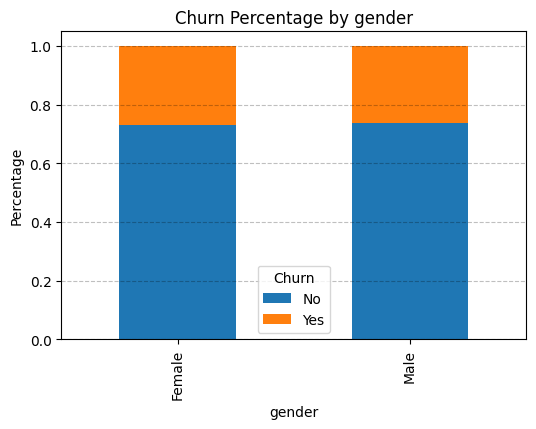

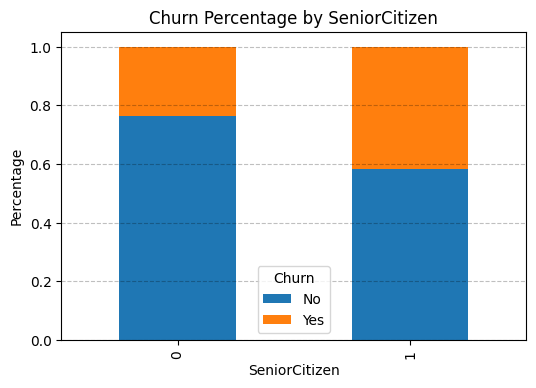

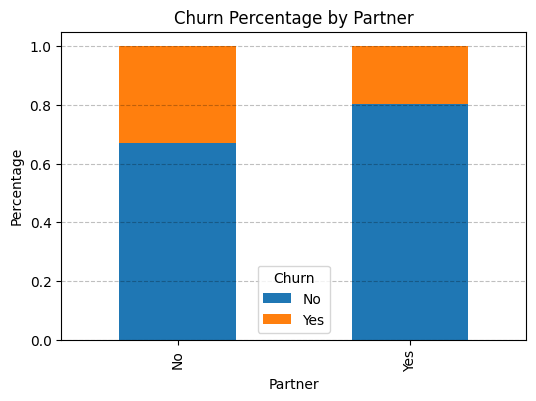

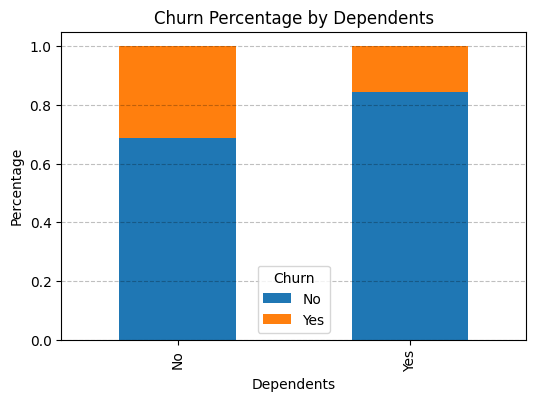

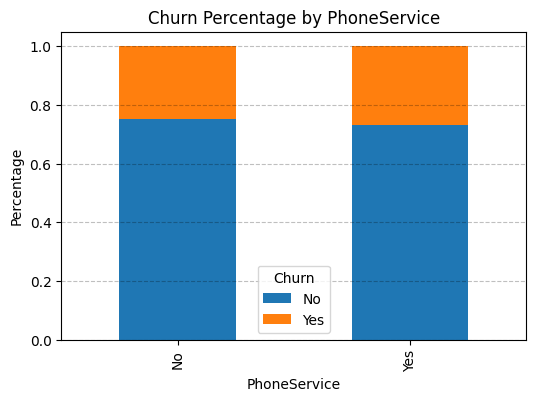

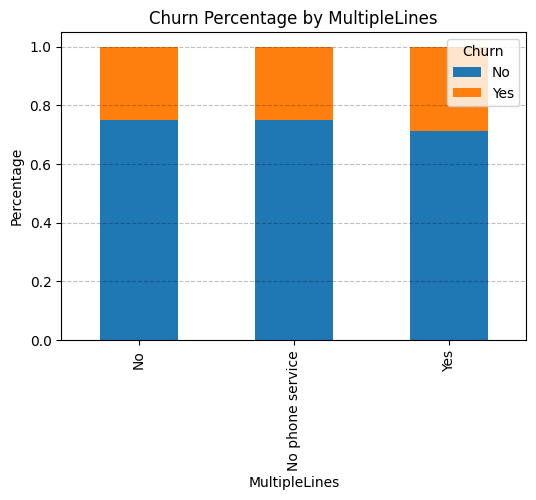

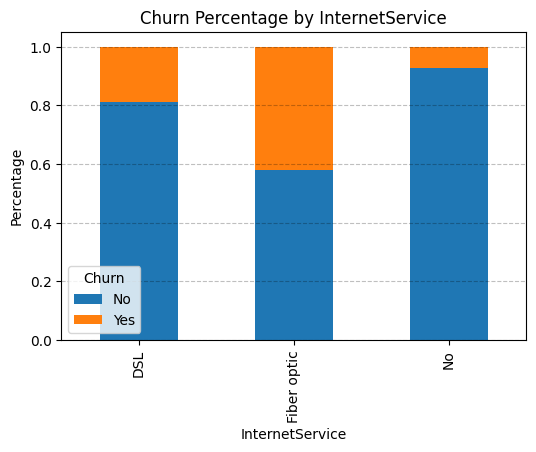

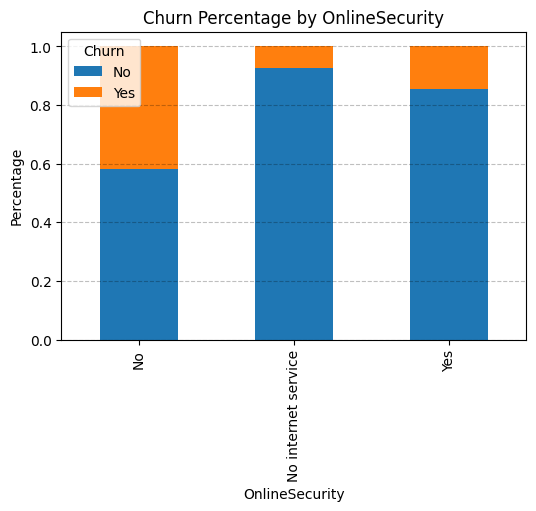

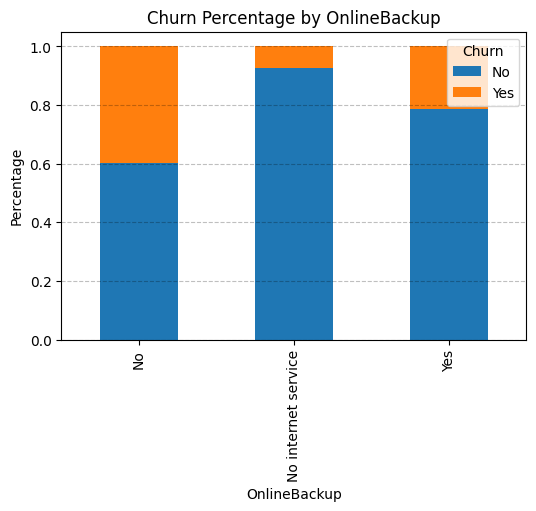

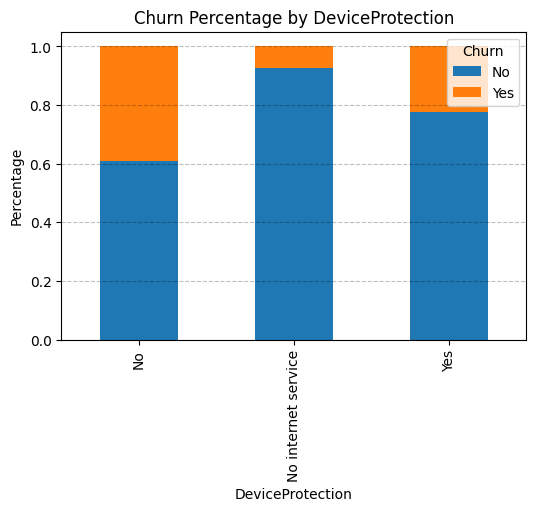

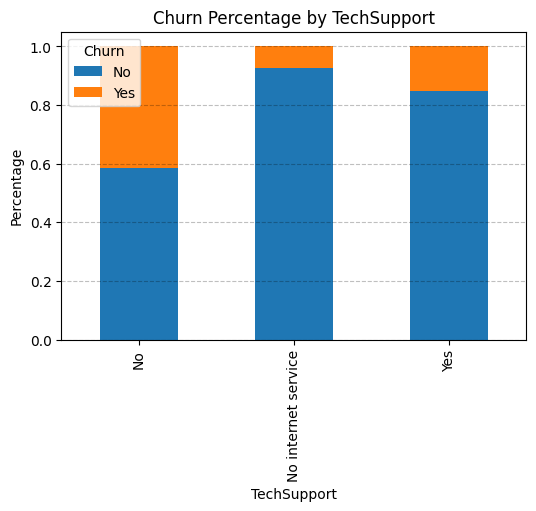

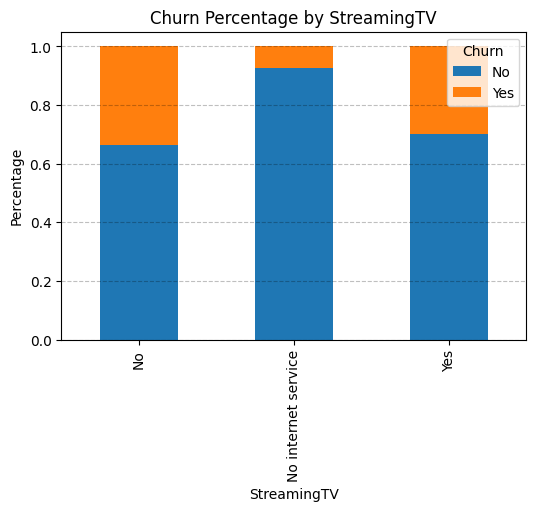

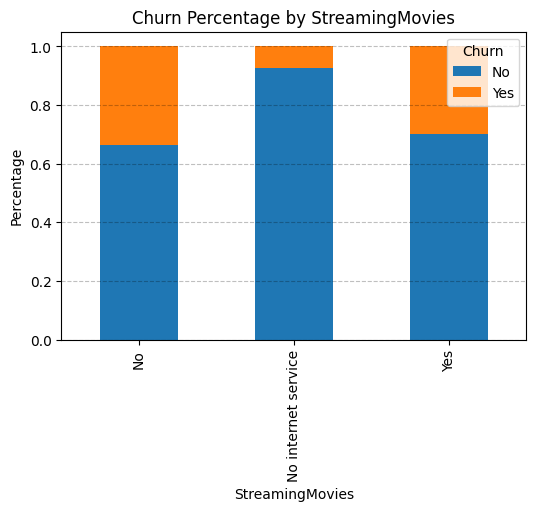

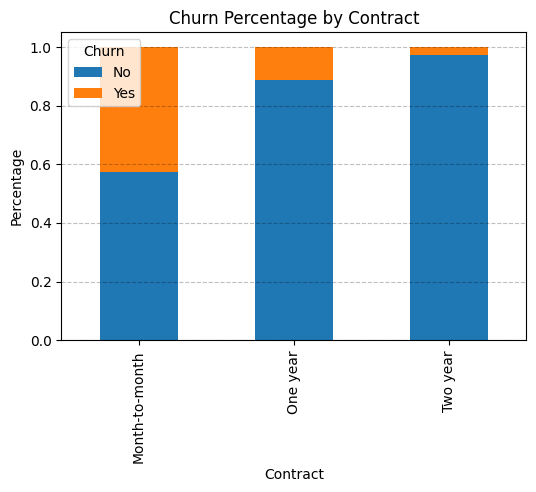

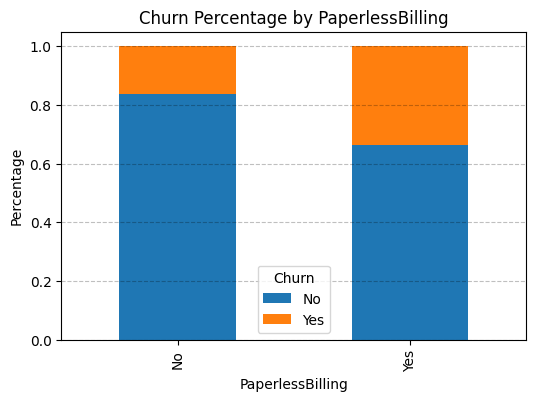

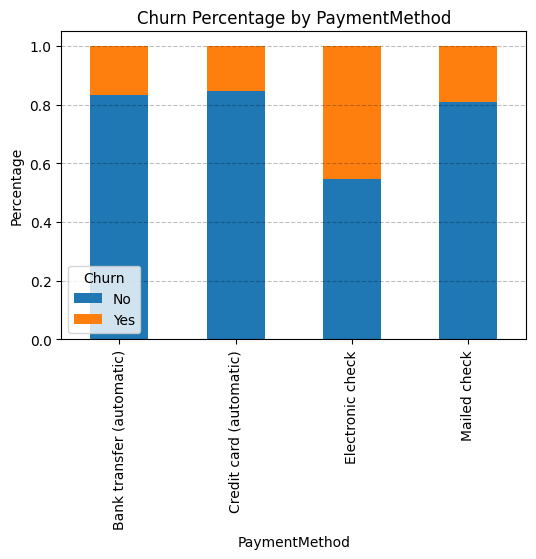

In [10]:
cat_columns=['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
for col in cat_columns:
    pd.crosstab(
    df[col],
    df["Churn"],
    normalize="index").plot(kind="bar", stacked=True, figsize=(6,4))

    plt.title(f"Churn Percentage by {col}")
    plt.grid(axis='y',linestyle='--',alpha=0.25,color="black")
    plt.ylabel("Percentage")
    plt.legend(title="Churn")
    plt.show()

* Gender does not show a significant relationship with customer churn. Male and female customers exhibit similar churn rates.
* Senior citizens have a higher churn rate compared to non-senior customers.
* Customers with no internet service are much less likely to churn than customers who subscribe to internet services.
* Customers without value-added services (such as Online Security, Tech Support, Device Protection, or Online Backup) tend to have a higher likelihood of churning.
* Contract duration has a strong influence on churn. Customers with longer-term contracts (one-year and two-year) are much more likely to stay, while customers on month-to-month contracts exhibit the highest churn rate.

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


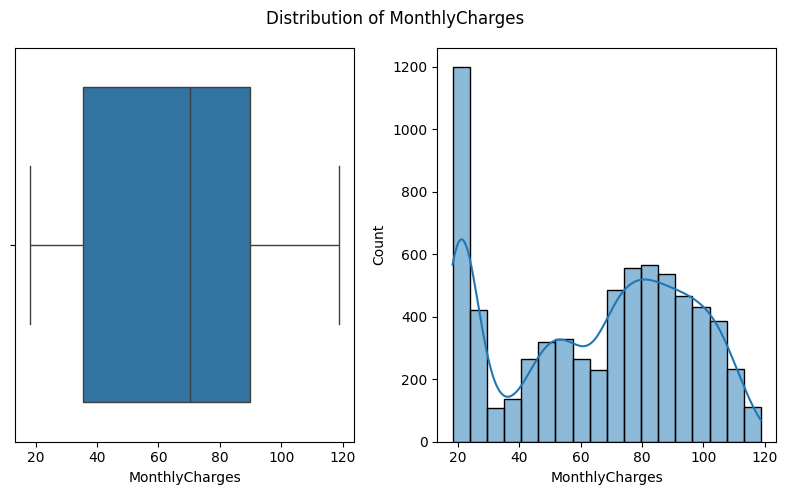

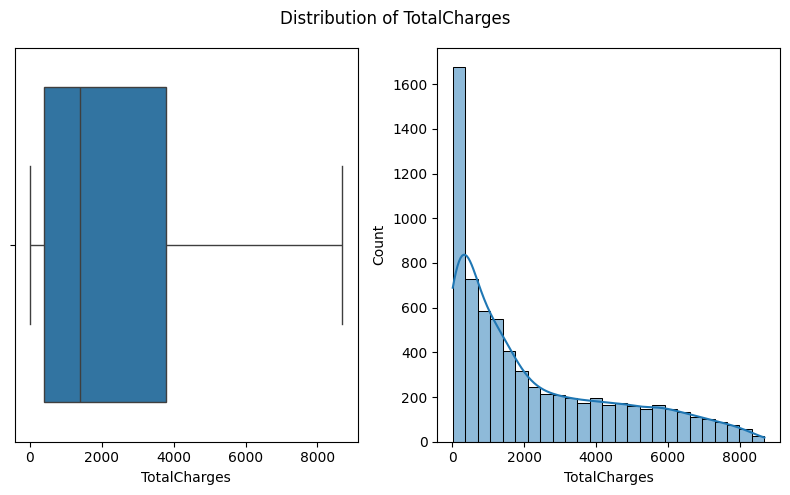

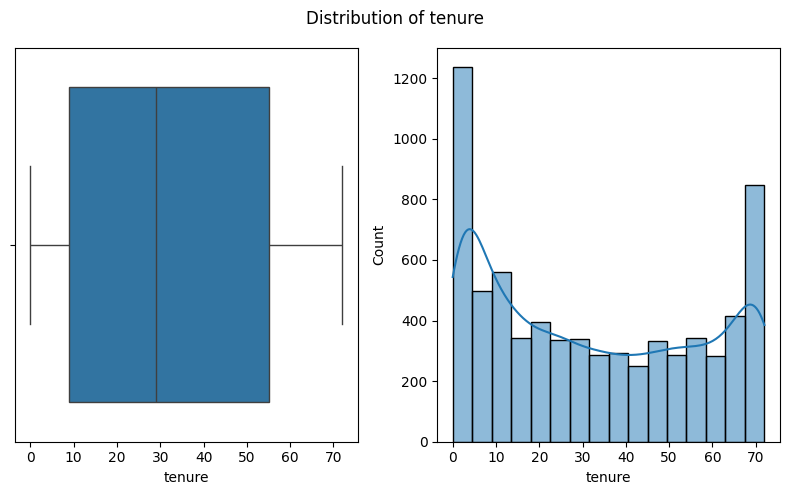

In [12]:
num_col=["MonthlyCharges",'TotalCharges','tenure']
for col in num_col:
    plt.figure(figsize=(8,5))
    plt.suptitle(f"Distribution of {col}")
    plt.subplot(1,2,1)
    sns.boxplot(x=df[col])
    plt.subplot(1,2,2)
    sns.histplot(x=df[col],kde=True)

    plt.tight_layout()
    plt.show()

In [13]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102652
tenure,0.016567,1.000000,0.247900,0.825464
MonthlyCharges,0.220173,0.247900,1.000000,0.650864
TotalCharges,0.102652,0.825464,0.650864,1.000000


In [14]:
x=df.drop(columns="Churn",axis=1)
y=df['Churn']

In [15]:
x=pd.get_dummies(x,drop_first=True)
y=y.map({
    "No":0,
    "Yes":1
})

In [16]:
x[['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']]=x[['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']].astype(int)

In [17]:
x

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1,1,1,1,0,1,...,0,1,0,1,1,0,1,0,0,1
7039,0,72,103.20,7362.90,0,1,1,1,0,1,...,0,1,0,1,1,0,1,1,0,0
7040,0,11,29.60,346.45,0,1,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,1


# Required modules

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import RandomizedSearchCV

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [20]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [21]:
scaled={"Logistic Regresion":LogisticRegression(),
"KNN":KNeighborsClassifier(),
"SVC":SVC()}
non_scaled={"Decision tree":DecisionTreeClassifier(random_state=42),
"Random forest":RandomForestClassifier(n_estimators=100,
                                       max_features= None,max_depth= 9, criterion= 'entropy',
                                      random_state=42),
"Naive bayes":GaussianNB()}

In [22]:
for name,model in scaled.items():
    print("="*50)
    print(f"model:  {name}")
    print("="*50)
    model.fit(x_train_scaled,y_train)
    y_pred=model.predict(x_test_scaled)

    print("accuracy:\n",accuracy_score(y_test,y_pred))
    print("precision score:\n",precision_score(y_test,y_pred))
    print("recall score:\n",recall_score(y_test,y_pred))
    print("f1 score:\n",f1_score(y_test,y_pred))
    print("roc auc score:\n",roc_auc_score(y_test,y_pred))
    print("confusion matrix\n",confusion_matrix(y_test,y_pred))
    print("classification_report:\n",classification_report(y_test,y_pred))
    print("\n")

model:  Logistic Regresion
accuracy:
 0.8163440860215053
precision score:
 0.686456400742115
recall score:
 0.589171974522293
f1 score:
 0.6341045415595544
roc auc score:
 0.7447922335781766
confusion matrix
 [[1528  169]
 [ 258  370]]
classification_report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1697
           1       0.69      0.59      0.63       628

    accuracy                           0.82      2325
   macro avg       0.77      0.74      0.76      2325
weighted avg       0.81      0.82      0.81      2325



model:  KNN
accuracy:
 0.7587096774193548
precision score:
 0.5553719008264463
recall score:
 0.535031847133758
f1 score:
 0.5450121654501217
roc auc score:
 0.6882584103081871
confusion matrix
 [[1428  269]
 [ 292  336]]
classification_report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.84      1697
           1       0.56      0.54      0.55       628

 

In [23]:
for name,model in non_scaled.items():
    print("="*50)
    print(f"model:  {name}")
    print("="*50)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

    print("accuracy:\n",accuracy_score(y_test,y_pred))
    print("precision score:\n",precision_score(y_test,y_pred))
    print("recall score:\n",recall_score(y_test,y_pred))
    print("f1 score:\n",f1_score(y_test,y_pred))
    print("roc auc score:\n",roc_auc_score(y_test,y_pred))
    print("confusion matrix\n",confusion_matrix(y_test,y_pred))
    print("classification_report:\n",classification_report(y_test,y_pred))
    print("\n")

model:  Decision tree
accuracy:
 0.7359139784946237
precision score:
 0.5106060606060606
recall score:
 0.5366242038216561
f1 score:
 0.5232919254658385
roc auc score:
 0.6731441584812464
confusion matrix
 [[1374  323]
 [ 291  337]]
classification_report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82      1697
           1       0.51      0.54      0.52       628

    accuracy                           0.74      2325
   macro avg       0.67      0.67      0.67      2325
weighted avg       0.74      0.74      0.74      2325



model:  Random forest
accuracy:
 0.7995698924731183
precision score:
 0.6594488188976378
recall score:
 0.5334394904458599
f1 score:
 0.5897887323943662
roc auc score:
 0.7157474411569311
confusion matrix
 [[1524  173]
 [ 293  335]]
classification_report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1697
           1       0.66      0.53      0.59     

# Hypertuning

**Random_forest**

In [24]:
model_1=RandomForestClassifier()
param_grid={
    "n_estimators":[50,100,125,150],
    "criterion":['gini','entropy'],
    "max_depth":[3,5,7,9,11,13],
    "max_features":["sqrt","log2", None]
}
classifier_1 = RandomizedSearchCV(
    estimator=model_1,
    param_distributions=param_grid,
    n_iter=5,
    cv=5,
    return_train_score=False,
    random_state=42,
)

classifier_1.fit(x_train, y_train)

print(classifier_1.best_params_)
print(classifier_1.best_score_)
print(classifier_1.best_estimator_)

{'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': 7, 'criterion': 'entropy'}
0.7954634505814476
RandomForestClassifier(criterion='entropy', max_depth=7)


**Logistic_regression**

In [25]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"],
    "max_iter": [100, 200, 500]
}
model_2=LogisticRegression()
classifier_2 = RandomizedSearchCV(
    estimator=model_2,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    return_train_score=False,
    random_state=42,
)
classifier_2.fit(x_train_scaled, y_train)

print(classifier_2.best_params_)
print(classifier_2.best_score_)
print(classifier_2.best_estimator_)

{'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 200, 'class_weight': None, 'C': 100}
0.8003414993619353
LogisticRegression(C=100, max_iter=200, penalty='l1', solver='liblinear')


*After tunning our model's all the scores have drooped so used default.*

In [26]:
from sklearn.pipeline import Pipeline
base_models = [
    ("lr", Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression())
    ])),
    
    ("svc", Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(probability=True))
    ])),
    
    ("rf",RandomForestClassifier(n_estimators=100,
                                max_features= None,max_depth= 9,
                                criterion= 'entropy',
                                random_state=42))
]

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

stack.fit(x_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('lr', LogisticRegression())])),
                               ('svc',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('svc',
                                                 SVC(probability=True))])),
                               ('rf',
                                RandomForestClassifier(criterion='entropy',
                                                       max_depth=9,
                                                       max_features=None,
                                                       random_state=42))],
                   final_estimator=LogisticRegression())

In [27]:
y_pred_stack = stack.predict(x_test)

In [28]:
print("accuracy:\n",accuracy_score(y_test,y_pred_stack))
print("precision score:\n",precision_score(y_test,y_pred_stack))
print("recall score:\n",recall_score(y_test,y_pred_stack))
print("f1 score:\n",f1_score(y_test,y_pred_stack))
print("roc auc score:\n",roc_auc_score(y_test,y_pred_stack))
print("confusion matrix\n",confusion_matrix(y_test,y_pred_stack))
print("classification_report:\n",classification_report(y_test,y_pred_stack))


accuracy:
 0.8120430107526881
precision score:
 0.6819047619047619
recall score:
 0.5700636942675159
f1 score:
 0.6209887250650477
roc auc score:
 0.7358273686423025
confusion matrix
 [[1530  167]
 [ 270  358]]
classification_report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.88      1697
           1       0.68      0.57      0.62       628

    accuracy                           0.81      2325
   macro avg       0.77      0.74      0.75      2325
weighted avg       0.80      0.81      0.81      2325



In [29]:
from xgboost import XGBClassifier

In [30]:
model_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)


In [31]:
model_xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [32]:
y_pred_xgb = model_xgb.predict(x_test)

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7905376344086021
Precision: 0.6312849162011173
Recall: 0.5398089171974523
F1 Score: 0.5819742489270386
ROC-AUC: 0.7115662146387969
[[1499  198]
 [ 289  339]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1697
           1       0.63      0.54      0.58       628

    accuracy                           0.79      2325
   macro avg       0.73      0.71      0.72      2325
weighted avg       0.78      0.79      0.79      2325



**Overall our Logistic regression model is predicting best.**

# Exporting our model in pkl file

In [34]:
import joblib
model_lr=LogisticRegression(random_state=42)
model_lr.fit(x_train_scaled,y_train)
joblib.dump(model_lr,"logistic_regression.pkl")
joblib.dump(scaler,"standard_scaler.pkl")

['standard_scaler.pkl']